In [4]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`

In [5]:
using Revise
includet("./base.jl")

In [6]:
includet("../../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

# Looking at one dataset tests

In [8]:
f = jldopen("./main1/gi58.jld2")
# f = jldopen("./main2/ri4.jld2")
df = f["df"]
df = @subset df :retcodes .== ReturnCode.Success :num_surv .!= 0
fmd = f["metadata"];
@show fmd.K, fmd.l, fmd.p
nrow(df), fmd.num_runs

(fmd.K, fmd.l, fmd.p) = (51.58113883008419, 0.999, 1.0)

(21, 25)

In [43]:
ks = range(0.01, 1000, 1000)
add_disprels!(df, ks);
fit_ds_v2!(df, ks, fmd.K, fmd.l, fmd.p)
add_mm_mrls_v2!(df, ks, fmd.K, fmd.l, fmd.p);
# fit_ds!(df, ks, fmd.T, fmd.K, fmd.l, fmd.p; N0=10000.)
# add_mm_mrls!(df, ks, fmd.T, fmd.K, fmd.l, fmd.p; N0=10000.);

## Looking at d fit quality

In [44]:
df.rfq = df.fit_quality ./ abs.(df.mmrls);

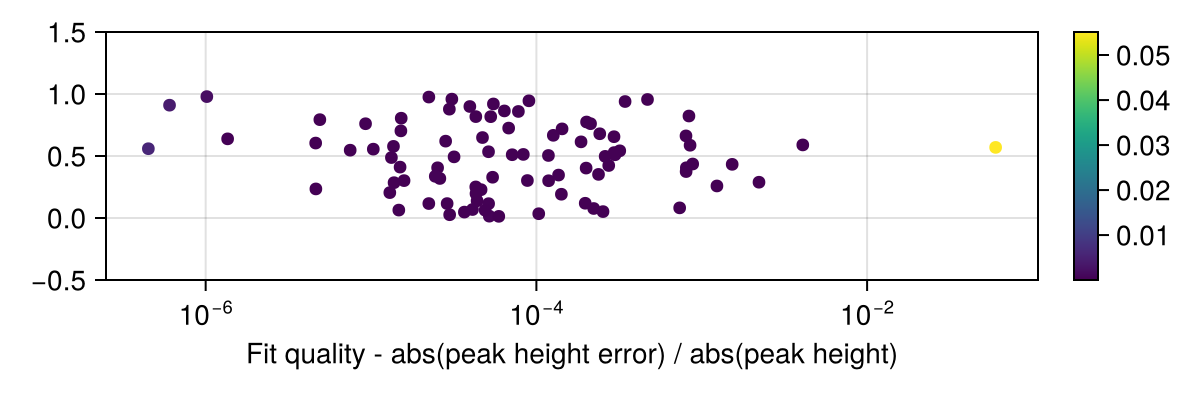

In [45]:
fap = scatter(df.rfq, rand(nrow(df));
    figure=(; size=(600, 200)),
    axis=(;
        xscale=log10,
        xlabel="Fit quality - abs(peak height error) / abs(peak height)"
    ),
    color=df.mmrls,
    # color=df.num_surv,
)
Colorbar(fap.figure[1,2], fap.plot)
ylims!(fap.axis, -0.5, 1.5)
fap

In [47]:
findmax(df.rfq)

(0.059875204046860496, 8)

In [51]:
r = df[8,:];

## Scatter plot

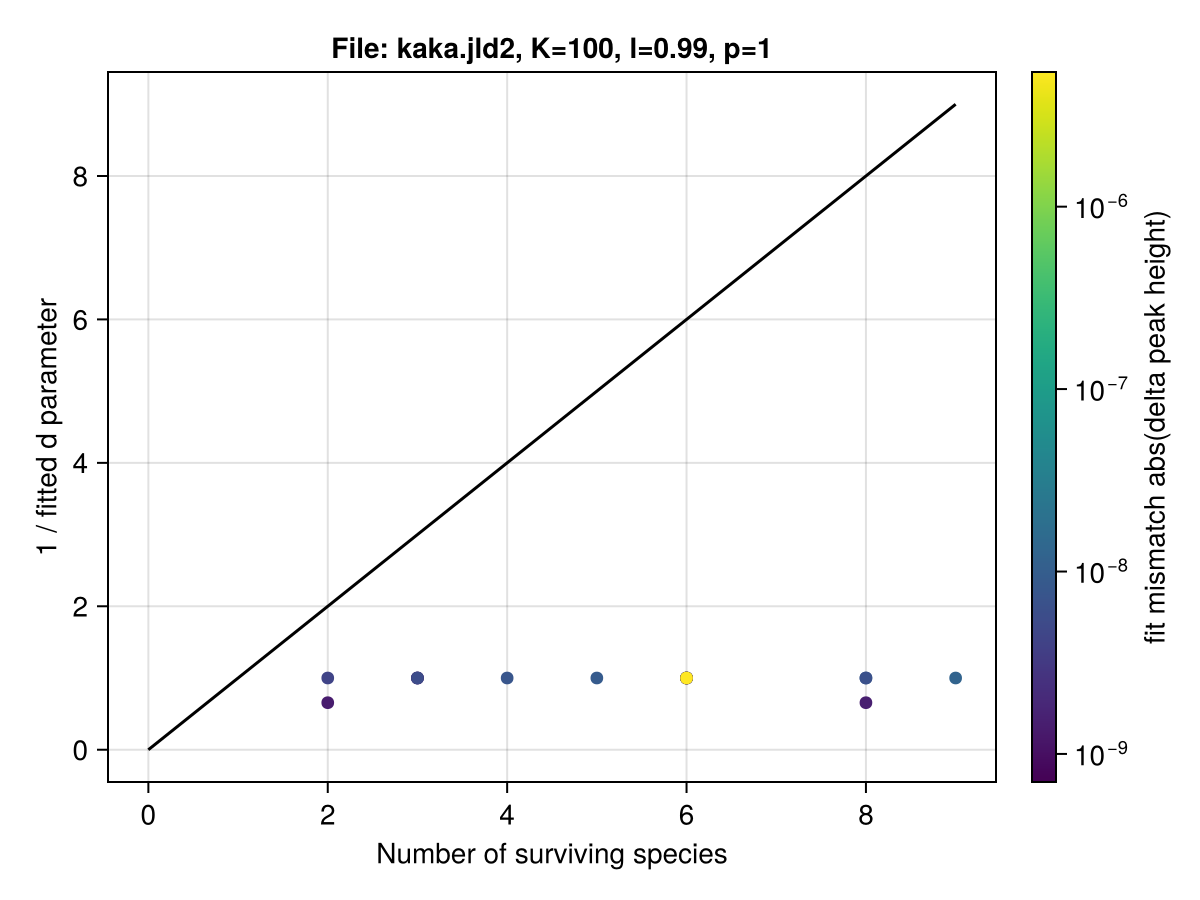

In [417]:
fap = scatter(df.num_surv, 1 ./ df.fit_ds;
    # color=clamp.(df.mmrls, minimum(filter(isposdef, df.mmrls)), Inf),
    # color=clamp.(df.tot_biom, 1e-1, Inf),
    # color=clamp.(xx, 1e-5, Inf),
    # color=xx,
    color=clamp.(df.fit_quality, 0., maximum(filter(<(1e-2), df.fit_quality))),
    # color=df.fit_func,
    colorscale=log10,
)
Colorbar(fap.figure[1,2], fap.plot;
    # label="max(real(lambdas)) - peak height"
    label="fit mismatch abs(delta peak height)"
)

fap.axis.title = (@sprintf "File: %s, K=%.5g, l=%.5g, p=%.5g" basename(f.path) fmd.K fmd.l fmd.p)
fap.axis.xlabel = "Number of surviving species"
fap.axis.ylabel = "1 / fitted d parameter"

mm = maximum(df.num_surv)
lines!(fap.axis, [0., mm], [0., mm]; color=:black)

# Makie.save("./num_surv_vs_invd_base.pdf", fap)
fap

## Looking at disprels

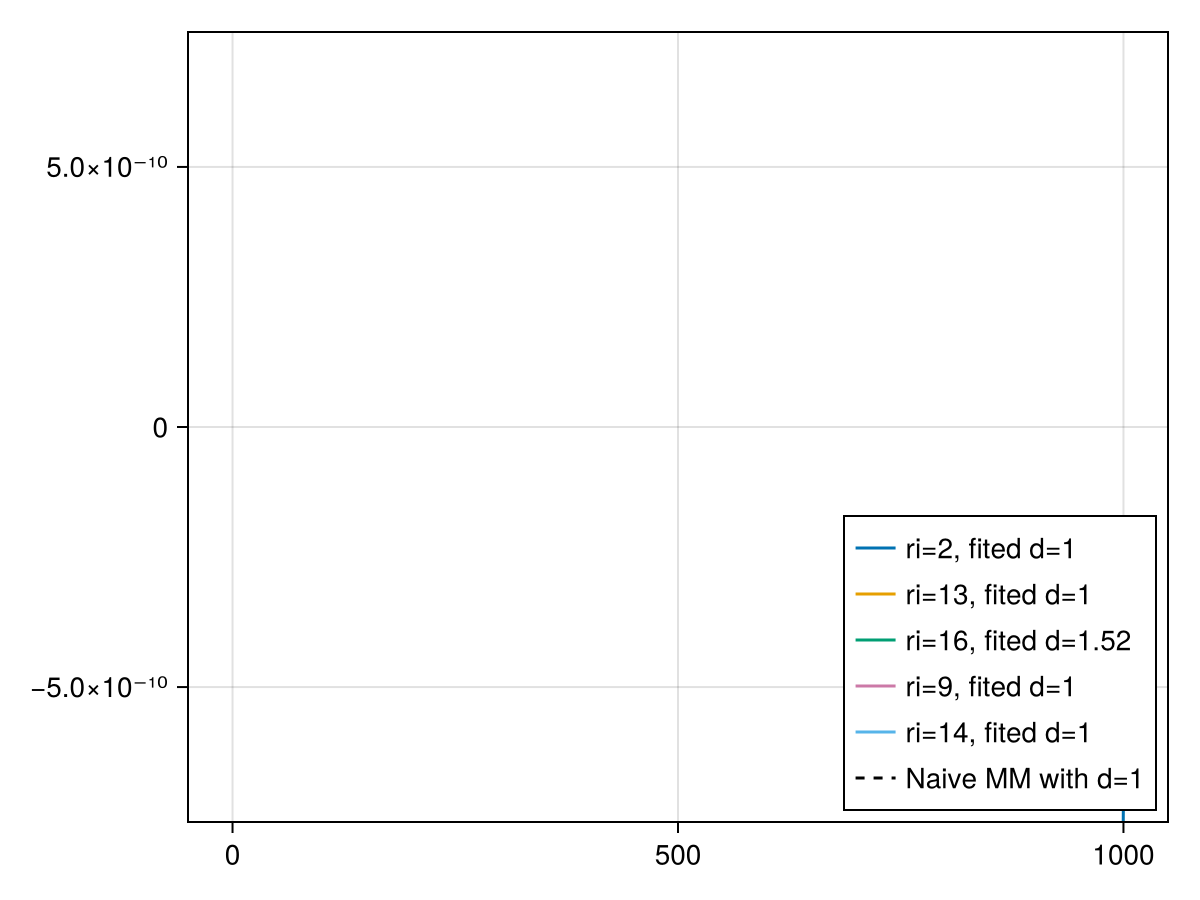

In [416]:
faa = plot_fitted_disprels(df, ks, 5)
naive_mm_mrls = get_naive_mm_mrls(ks, fmd.K, fmd.l, fmd.p; DN=fmd.DN)
lines!(faa.axis, ks, naive_mm_mrls;
    linestyle=:dash,
    color=:black,
    label="Naive MM with d=1"
)
axislegend(faa.axis; position=:rb)
# Makie.save("./fitted_disprel1.pdf", fig)
faa.figure

## Rest

In [70]:
r = df[8,:];

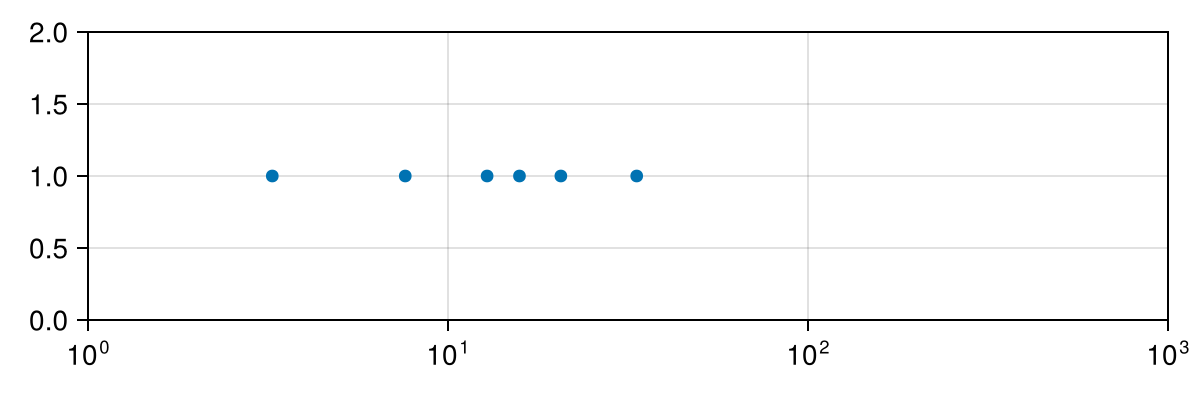

In [71]:
fap = scatter(r.final_states[1:fmd.N], fill(1, fmd.N);
    figure=(; size=(600, 200)),
    axis=(;
        xscale=log10,
        # xlabel="Fit quality - abs(peak height error) / abs(peak height)"
    ),
    # color=df.mmrls,
    # color=df.num_surv,
)
# ylims!(fap.axis, -0.5, 1.5)
fap

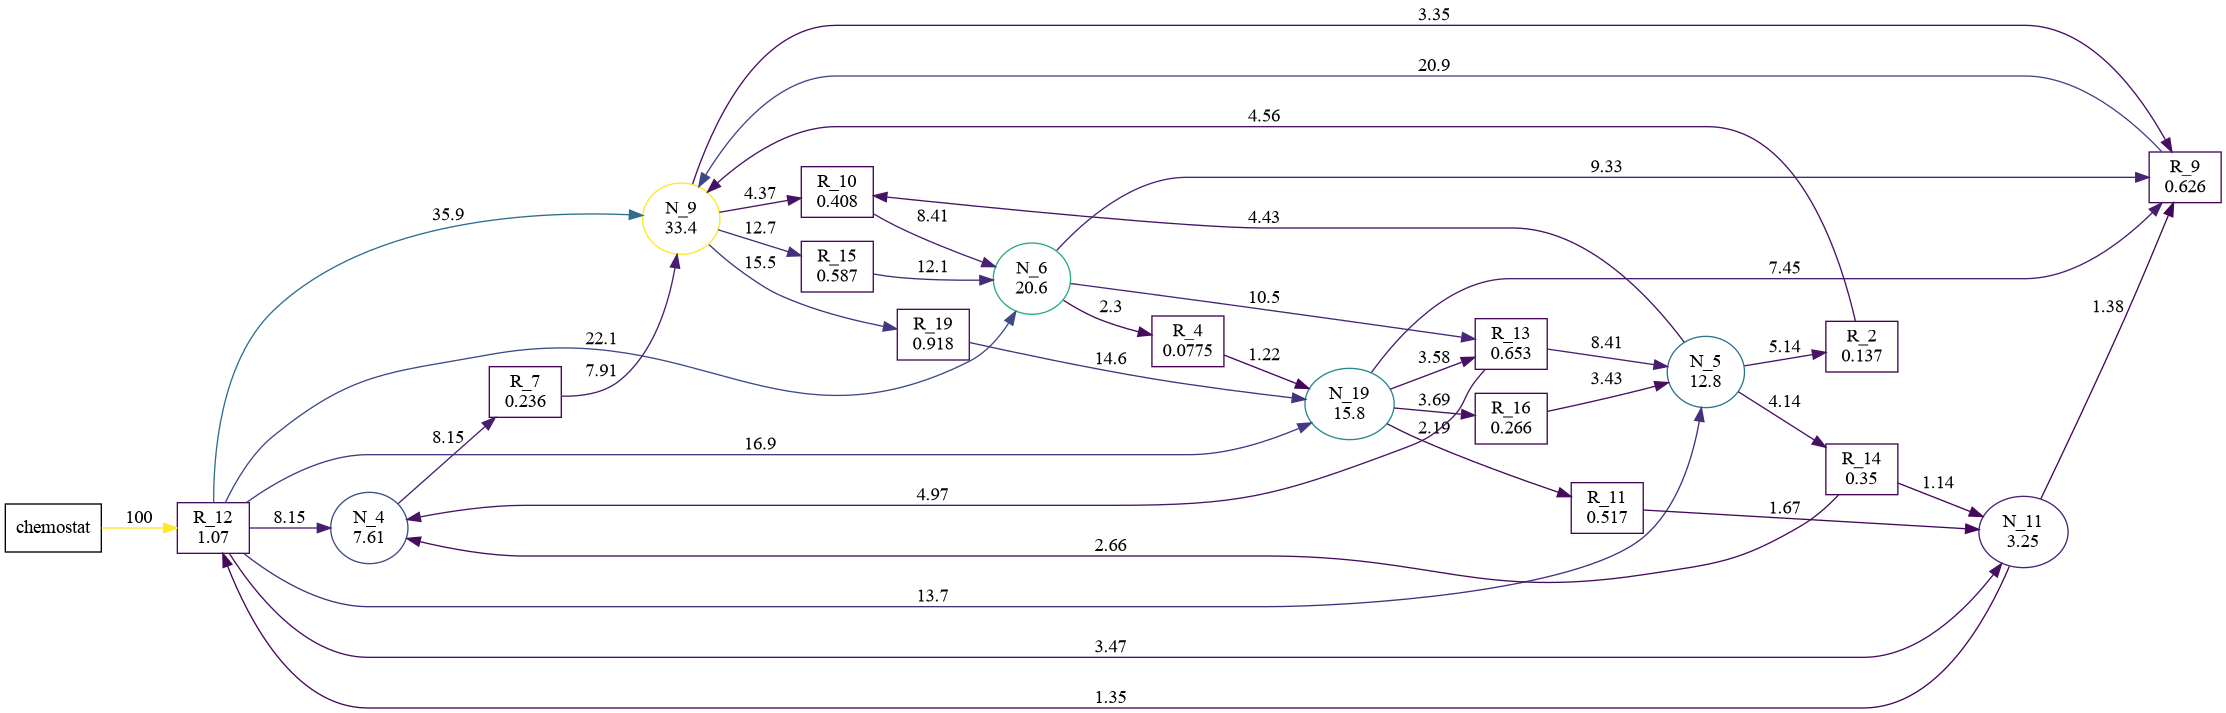

In [72]:
display(MIME("image/png"), diagram_sfss_v3(r.params, r.final_states;
    strain_threshold=1.,
    edge_threshold=1.,
))

In [73]:
r.fit_ds

0.01221958746608896

r.fit_ds = 0.01221958746608896
r.maxresids = 8.881784197001252e-15

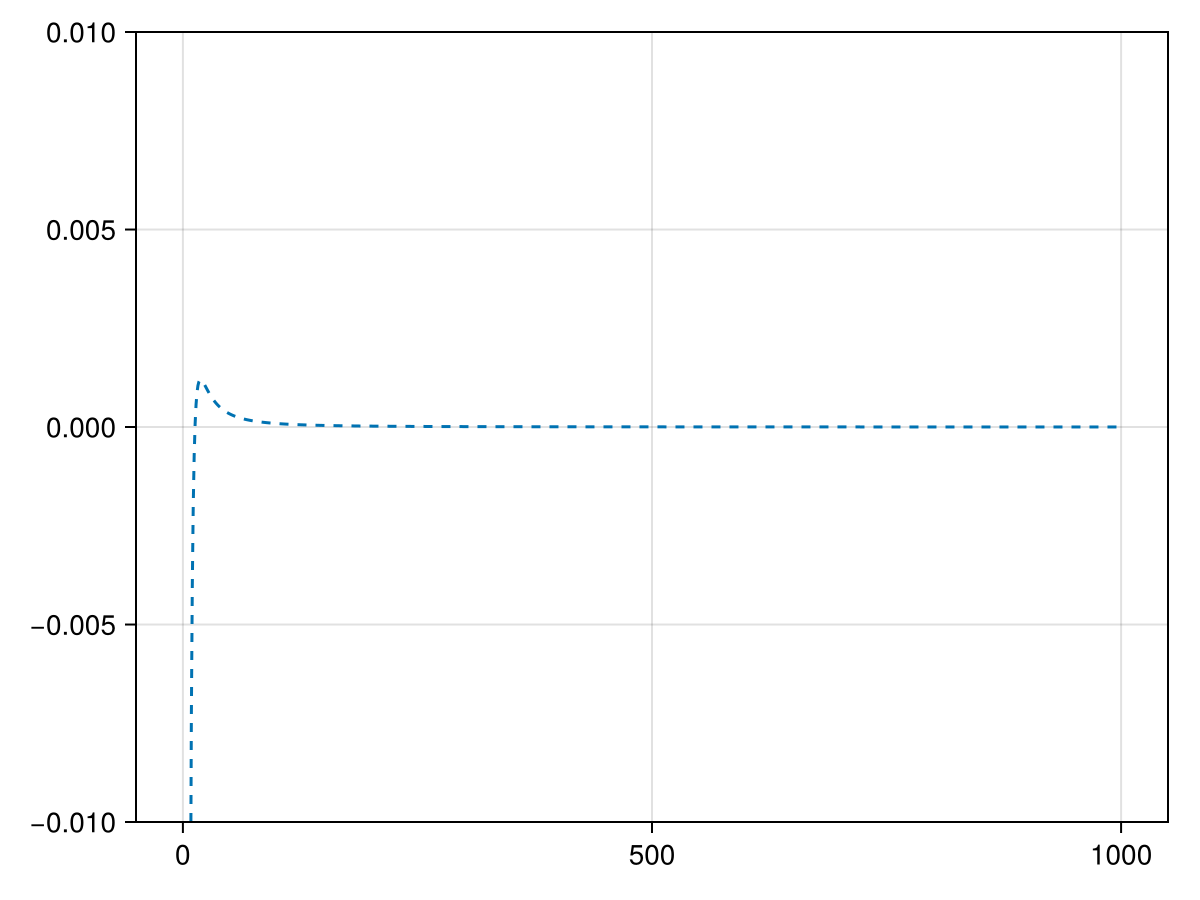

In [74]:
fig = Figure()
ax = Axis(fig[1,1])

@show r.fit_ds r.maxresids

mmp = MMParams(;
    K=fmd.K, l=fmd.l,
    m=1., c=1.,
    d=0.10,
    k=0.5,
)
mm_Ds = [fmd.DN, 1., fmd.p]
mm_ps = mmp_to_mmicrm(mmp; static=false)
mm_fs = get_mm_the_nonext_sol(mmp)
mm_mrls = linstab_simple(mm_ps, mm_Ds, mm_fs, ks)

lines!(ks, r.mrls)
lines!(ks, mm_mrls;
    color=Cycled(1),
    linestyle=:dash,
)

ylims!(ax, -0.01, 0.01)

fig

## Optimizing k and D[1,2,1] too

In [58]:
opt_factor = 1e-5
test_threshold = 1e-9

opt_r = optimize([1., 0., 0.9], NelderMead()) do u
    mmp = MMParams(;
        K=fmd.K, l=fmd.l,
        m=1., c=1.,
        d=u[1],
        k=u[2],
    )
    mm_Ds = [fmd.DN, 1., fmd.p]
    mm_ps = mmp_to_mmicrm(mmp; static=false)
    mm_ps.D[1,2,1] = u[3]

    mm_p = make_mmicrm_problem(mm_ps, [10000., 0., 0.], 1e8)
    tol = 1e-9
    mm_s = solve(mm_p, QNDF();
        callback=CallbackSet(make_timer_callback(10.), PositiveDomain([1., 0., 0.])),
        abstol=tol,
        reltol=tol,
    )
    mm_fs = mm_s.u[end]

    mresid = mmicrmmaxresid(mm_fs, mm_ps)
    if (mresid > test_threshold) || (mm_fs[1] < test_threshold)
        return Inf
    end

    mm_mrls = linstab_simple(mm_ps, mm_Ds, mm_fs, ks)
    (mm_mmrl, mm_ii) = findmax(mm_mrls)
    (r_mmrl, r_ii) = findmax(r.mrls)
    (mm_mmrl - r_mmrl)^2 + opt_factor * (ks[mm_ii] - ks[r_ii])^2
end;
@show opt_r.minimum opt_r.minimizer;

opt_r.minimum = 4.677176250733738
opt_r.minimizer = [1.525, 0.0, 0.9]

r.fit_ds = 0.01221958746608896
r.maxresids = 8.881784197001252e-15

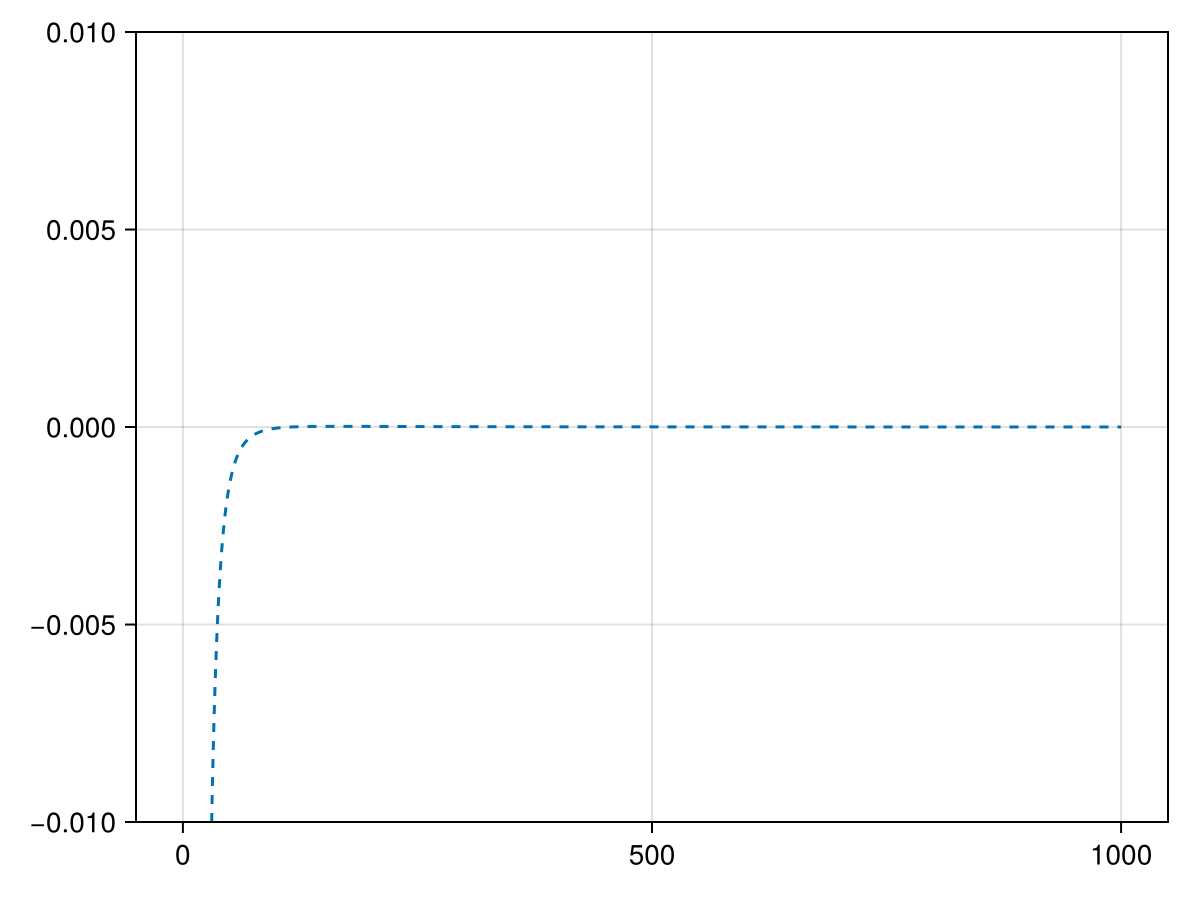

In [61]:
fig = Figure()
ax = Axis(fig[1,1])

@show r.fit_ds r.maxresids

mmp = MMParams(;
    K=fmd.K, l=fmd.l,
    m=1., c=1.,
    d=opt_r.minimizer[1],
    k=opt_r.minimizer[2],
)
mm_Ds = [fmd.DN, 1., fmd.p]
mm_ps = mmp_to_mmicrm(mmp; static=false)
mm_ps.D[1,2,1] = opt_r.minimizer[3]

mm_p = make_mmicrm_problem(mm_ps, [10000., 0., 0.], 1e8)
tol = 1e-9
mm_s = solve(mm_p, QNDF();
    callback=CallbackSet(make_timer_callback(10.), PositiveDomain([1., 0., 0.])),
    abstol=tol,
    reltol=tol,
)
mm_fs = mm_s.u[end]

# mm_fs = get_mm_the_nonext_sol(mmp)

mm_mrls = linstab_simple(mm_ps, mm_Ds, mm_fs, ks)

lines!(ax, ks, r.mrls)
lines!(ax, ks, mm_mrls;
    color=Cycled(1),
    linestyle=:dash,
)

ylims!(ax, -0.01, 0.01)

# display(GLMakie.Screen(), fig)

fig

In [62]:
r.mrls

1000-element Vector{Float64}:
 0.0551162489672522
 0.055116248967250724
 0.055116248967254186
 0.05511624896725433
 0.055116248967253756
 0.05511624896724523
 0.05511624896725053
 0.05511624896726209
 0.055116248967260015
 0.05511624896725081
 0.05511624896723314
 0.05511624896726607
 0.055116248967264705
 ⋮
 0.05511624884199496
 0.05511624899932722
 0.055116248982361886
 0.055116249151125875
 0.055116248800572344
 0.055116249038656515
 0.05511624893885691
 0.05511624893118315
 0.055116249100457794
 0.05511624899756163
 0.0551162491510508
 0.05511624908350155